# Accessing an APOGEE Spectrum with sdss-access

## Learning Goals
By the end of this tutorial, you will:
- Understand how to retrieve SDSS data with sdss-access
- Understand some of the structure of a fits file containing an APOGEE spectrum
- (Optionally) have a copy of the AllStarASPCAP file

## Introduction
The Apache Point Observatory Galactic Evolution Experiment (APOGEE) is an infrared spectroscopic survey using two spectrographs at the two SDSS V observatories, Apache Point Observatory (APO) and Las Campanas Observatory (LCO).

In this short tutorial we will briefly cover how to retrieve an object's sdss_id from the allStarASPCAP file, then show how to use the sdss-access tool to retreive the APOGEE spectrum of that star from the SDSS Science Archive Server (SAS).

## Imports
This tutorial requires two commonly used python packages, and an SDSS specific package
- _matplotlib_ for plotting
- _astropy_ for reading fits table
- _numpy_ for doing array math
- _sdss-access_ for accessing data on the SAS

Missing packages can be installed via `pip install matplotlib astropy numpy sdss-access` 

NOTE: You may want to set the `$SAS_BASE_DIR` environment variable before starting this notebook, other wise `$HOME/sas` will be created and used

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

from sdss_access import Access
access = Access(release='ipl-4')

Other tutorials give examples of using the astra allStar files to find ID numbers and other information. Since we're only interested in accessing spectra, we'll skip loading that large file for now and simply assume we know an sdss_id.

In [2]:
sdss_id = 94846885 

## sdss-access

sdss-access has extensive [documentation](https://sdss-access.readthedocs.io/en/latest/), but we should mention a few things. First if you are a member of the collaboration accessing proprietary data, you need to set up a [.netrc file](https://sdss-access.readthedocs.io/en/latest/auth.html). After that usage is the same for everyone.

You need specify the file species you need, in this case 'mwmStar', then a series of key word arguments that vary depending on the file species. A list of file species and their keyword arugments is [available](https://sdss-access.readthedocs.io/en/latest/paths.html).

The code block below showa an example of retreiving an sdss spectrum. First we construct the SAS file path with `access.full`, then we check to see if the file exists. If you are running this notebook on SciServer, or another system with a full copy of the SAS, or if you have downloaded this specific file before, we can skip downloading the data. Otherwise, `access.commit()` will retrieve the file and save it to your local SAS, `$SAS_BASE_DIR`, with the same structure as the SAS (so it will be many files deep). Note: it is important to skip the download step if the file already exists locally. Attempting to download a file that already exists can cause errors on some systems.

In [3]:
mwmStar_filename = access.full('mwmStar', v_astra='0.8.1', component='', sdss_id=sdss_id)
if not access.exists('',full=mwmStar_filename):
    access.remote()
    access.add('mwmStar', v_astra='0.8.0', component='', sdss_id=sdss_id)
    access.set_stream()
    access.commit()
    mwmStar_filename = access.full('mwmStar', v_astra='0.8.1', component='', sdss_id=sdss_id)

access.exists('', full=mwmStar_filename)

True

## Load the spectrum

Now use `astropy.Table` load the data. HDU 3 contains the APO spectrum.

We then extract wavelength, flux, and ivar (inverse variance) to more convenient variables. Not we need the `[0]` entry. This is part of the file structure meant to be as similar as possible to other file species, which contain separat espectra for each visit. 

$ivar^{1/2}$ is a good representation of uncertainty in the flux

In [4]:
mwmStar = Table.read(mwmStar_filename, hdu=3)

obs_wl = mwmStar["wavelength"][0]
obs_flux = mwmStar["flux"][0]
obs_err = mwmStar["ivar"][0]**(-0.5)

[WARNING]: /var/folders/nd/01s30xjn2z1_lx_f3bqdbwt4nm074c/T/ipykernel_6237/3069109418.py:5: RuntimeWarning: divide by zero encountered in power
  obs_err = mwmStar["ivar"][0]**(-0.5)



In [5]:
mwmStar

spectrum_pk,release,filetype,v_astra,healpix,sdss_id,apred,obj,telescope,min_mjd,max_mjd,n_entries,n_visits,n_good_visits,n_good_rvs,snr,mean_fiber,std_fiber,spectrum_flags,v_rad,e_v_rad,std_v_rad,median_e_v_rad,doppler_teff,doppler_e_teff,doppler_logg,doppler_e_logg,doppler_fe_h,doppler_e_fe_h,doppler_rchi2,doppler_flags,xcorr_v_rad,xcorr_v_rel,xcorr_e_v_rel,ccfwhm,autofwhm,n_components,wavelength,flux,ivar,pixel_flags,continuum,nmf_rectified_model_flux,nmf_rchi2,nmf_flags
int64,bytes5,bytes6,bytes5,int32,int64,bytes3,bytes18,bytes6,int32,int32,int32,int32,int32,int32,float32,float32,float32,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float32,float32,float32,float32,float32,int32,float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32[8575],float32,int64
39108224,sdss5,apStar,0.8.0,110411,94846885,1.5,2M03322788-0658199,apo25m,60589,60589,-1,1,1,1,162.82494,251.0,0.0,0,91.72288,0.0,0.0,--,4615.0894,17.50829,4.999999,0.028501041,-1.1805744,0.013583928,3.2455409,0,--,--,--,--,--,1,15100.802 .. 16999.807,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,-- .. --,9.111334,0


Now plot the spectrum, flux vs wavelength.

Note the mask.

Text(0, 0.5, 'flux')

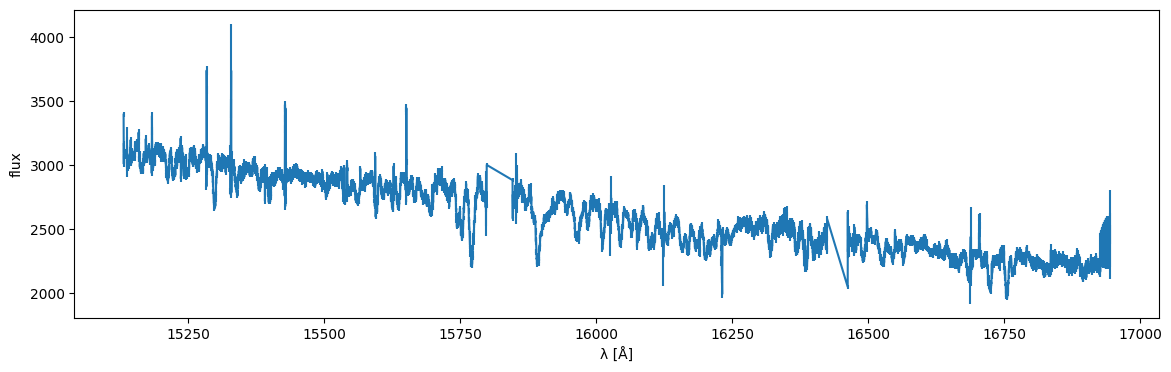

In [6]:
plt.figure(figsize=(14,4))

mask = obs_err < 0.1 * obs_flux

plt.errorbar(obs_wl[mask], obs_flux[mask], yerr=obs_err[mask])
plt.xlabel("λ [Å]")
plt.ylabel("flux")

A continuum fit is also provided, allowing us to continuum normalize the observed spectrum.

[WARNING]: /var/folders/nd/01s30xjn2z1_lx_f3bqdbwt4nm074c/T/ipykernel_6237/1282916058.py:10: RuntimeWarning: divide by zero encountered in divide
  norm_flux = flux / continuum



Text(0, 0.5, 'normlized flux')

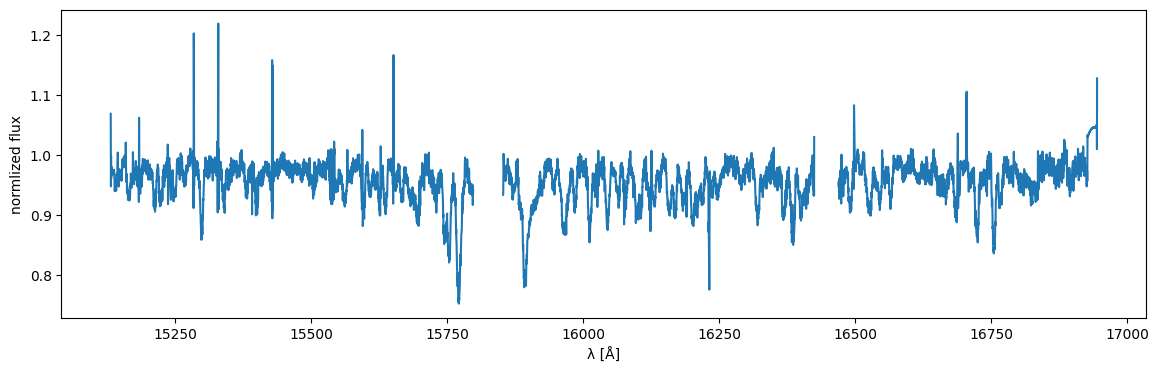

In [7]:
plt.figure(figsize=(14,4))

mask = obs_err < 0.1 * obs_flux

wl_plot = obs_wl[mask]
flux = obs_flux[mask]

continuum = mwmStar["continuum"][0][mask]

norm_flux = flux / continuum

plt.plot(wl_plot, norm_flux)
plt.xlabel("λ [Å]")
plt.ylabel("normlized flux")

### About this notebook

This notebook was created to give an example of using the `sdss-access` tool, and illustrate how to use an APOGEE spectrum.

**Authors**: Adam Wheeler, John Donor

**Last Update**: 2026 March 04

If you use `astropy`  for published research, please cite the
authors. Follow this link for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.